# 7. Non-standard subsystems: Van der Pol meets Bouc-Wen

Nothing in the framework assumes masses and springs. `07_vanderpol_boucwen.yaml`
couples a **Van der Pol** oscillator with an unknown nonlinearity `mu` (UKF, RK4) to
a **Bouc-Wen** hysteretic element with unknown `beta` and `gamma` (CKF) through a
spring-damper interface, with Gauss-Seidel messages. Both subsystems are written as
equation strings (`model: custom`, needs `sympy`); the ground truth is the same
coupled model simulated with the true parameters.

In [1]:
import pci

print(open("07_vanderpol_boucwen.yaml").read())

# Two non-standard subsystems written as equation strings (model: custom): a Van der Pol oscillator with
# unknown mu (UKF, RK4) coupled by a spring-damper to a Bouc-Wen hysteretic element with unknown beta, gamma (CKF).
# Solve with:  pci.solve("07_vanderpol_boucwen.yaml")
model: custom
subsystems:
  VdP:
    states: [q, v]
    inputs: [f]
    parameters: {m: 1.0, w: 2.0}
    unknowns: {mu: {initial: 0.4, std: 0.5}}
    equations: {q: v, v: (f + mu*(1 - q**2)*v - w**2*q) / m}
    measurements: {a_vdp: (f + mu*(1 - q**2)*v - w**2*q) / m}
    noise_std: {a_vdp: 1.0e-2}
    filter: ukf
    integrator: rk4
    x0: {q: 0.5}
  BW:
    states: [q, v, z]
    inputs: [f]
    parameters: {m: 1.0, c: 0.1, alpha: 0.5, k: 100.0, A: 1.0, n: 1.0}
    unknowns: {beta: {initial: 0.2, std: 0.3}, gamma: {initial: 0.2, std: 0.3}}
    equations:
      q: v
      v: (f - c*v - alpha*k*q - (1 - alpha)*k*z) / m
      z: A*v - beta*Abs(v)*Abs(z)**(n - 1)*z - gamma*v*Abs(z)**n
    measurements: {q_bw: q, a_bw:

## Solve

In [2]:
results = pci.solve("07_vanderpol_boucwen.yaml")
print(results.summary(start=15.0))

mode=estimate  schedule=GaussSeidel(iterations=1)  steps=30000  runtime=8.86s
[VdP]
           q: final= 0.0868233  std= 3.48e-05  rmse= 0.002573
           v: final=-6.68064  std= 7.03e-05  rmse= 0.0136
          mu: final= 0.983961  std= 1.53e-05  true= 1  rmse= 0.01827
[BW]
           q: final=-0.0175845  std= 1.05e-05  rmse= 0.0004719
           v: final=-2.33768  std= 7.79e-05  rmse= 0.005201
           z: final=-0.0266072  std= 1.26e-05  rmse= 0.0007992
        beta: final= 0.52721  std= 4.28e-05  true= 0.5  rmse= 0.03134
       gamma: final= 0.501493  std= 4.47e-05  true= 0.5  rmse= 0.01488
[messages] F_link


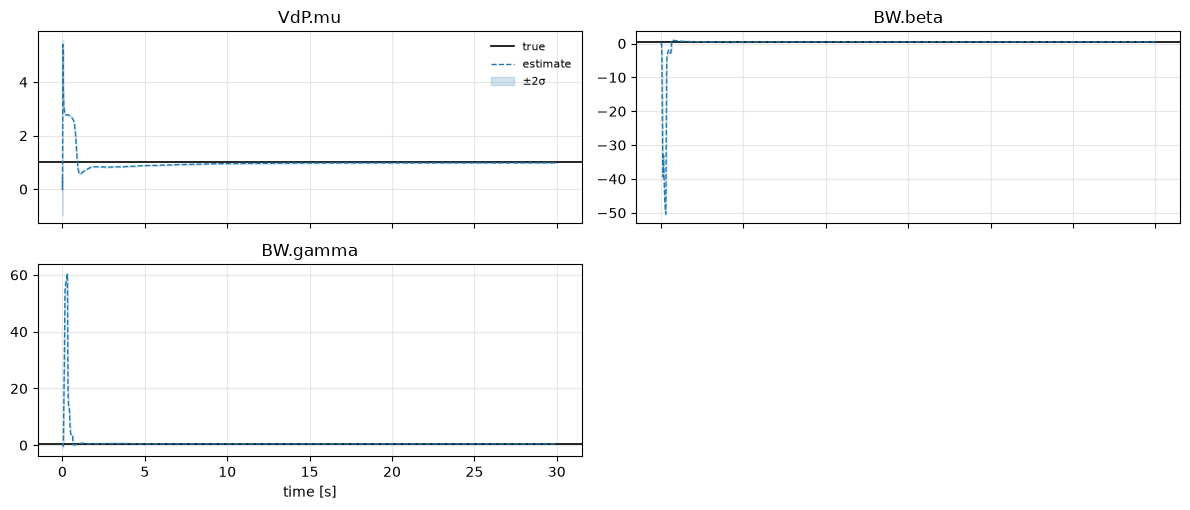

In [3]:
results.plot_parameters();

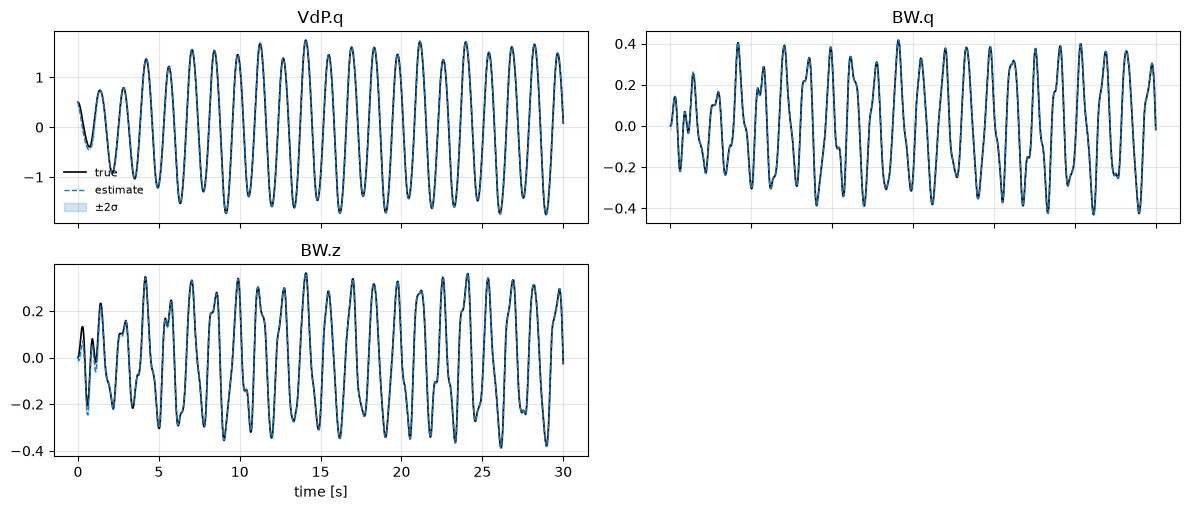

In [4]:
results.plot_states(["VdP.q", "BW.q", "BW.z"]);

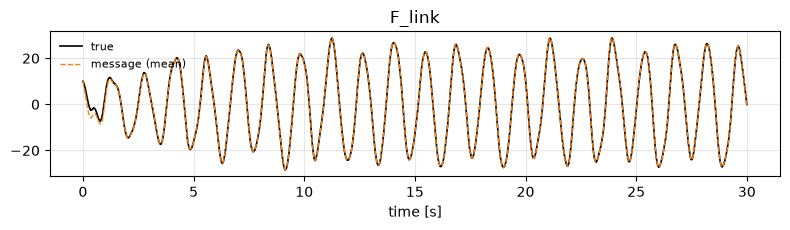

In [5]:
results.plot_messages();

The hysteretic variable `z` of the Bouc-Wen element is not measured; it is
reconstructed from the displacement and acceleration sensors together with the
parameters. `Abs` in the equations is the sympy absolute value, so the CKF sigma
points pass through the non-smooth term without a Jacobian.